# TransJakarta Bus Allocation — 1D LSTM Forecasting (PyTorch)

**Input:** `bus_besar_all.csv` dan `bus_kecil_all.csv`  
**Model:** 1D LSTM — sequence 7 hari ke belakang → prediksi hari ini  
**Output:** Total bus yang dibutuhkan per corridor **per jam** hari ini  
**Logika:** `total_hari_ini = alokasi_eksisting + 1` jika model prediksi overload, else `alokasi_eksisting`  
**Framework:** PyTorch


In [1]:
!pip install torch scikit-learn pandas numpy matplotlib seaborn tqdm -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm

pd.set_option('display.max_columns', 50)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## Config


In [3]:
BIG_BUS_CSV   = 'bus_besar_all.csv'
SMALL_BUS_CSV = 'bus_kecil_all.csv'

PRIORITY_THRESH = 6    # priority seat threshold → senior per bus besar
SMALL_CAPACITY  = 15   # kapasitas bus kecil
SENIOR_CUTOFF   = 1980 # born <= ini = senior

LOOKBACK_DAYS   = 7    # sequence input LSTM
FORECAST_DAYS   = 1    # prediksi 1 hari (hari ini)

EPOCHS          = 80
BATCH_SIZE      = 32
PATIENCE        = 15
LR              = 1e-3

# ── Class-imbalance fixes ─────────────────────────────────────────────────────
POS_WEIGHT      = 8.0   # BCEWithLogitsLoss pos_weight: bobot kelas overload
OVERSAMPLE      = True  # oversampling minority class di training set
THRESHOLD       = 0.35  # classification threshold (turunkan agar recall naik)



## ⚙️ [OPSIONAL] Generate Synthetic Dataset

Jalankan cell ini jika belum punya `bus_besar_all.csv` dan `bus_kecil_all.csv`.  
Data sintetis mencakup **1 Jan 2024 – 30 Jun 2024** (181 hari) dengan:  
- Pola **peak hour** pagi (07–09) dan sore (17–19)  
- Penumpang lebih sepi di **akhir pekan**  
- Distribusi `payCardBirthDate` realistis (campuran senior & non-senior)  
- Durasi perjalanan acak 5–45 menit  


In [4]:
from datetime import date, timedelta

# ---------------------------------------------------------------------------
# SYNTHETIC DATA GENERATOR
# Jalankan cell ini sekali untuk membuat bus_besar_all.csv & bus_kecil_all.csv
# ---------------------------------------------------------------------------

RNG   = np.random.default_rng(42)
START = date(2024, 1, 1)
END   = date(2024, 6, 30)
DATES = [START + timedelta(d) for d in range((END - START).days + 1)]

BIG_CORRIDORS = [
    '1','2','3','4','5','6','7','8','9','10',
    '1A','1B','2A','3A','5M','6C','6H','7D','10D',
    'B11','B13','D11','S11','T11',
]
SMALL_CORRIDORS = [
    'JAK.01','JAK.02','JAK.03','JAK.04','JAK.05',
    'JAK.06','JAK.07','JAK.08','JAK.10','JAK.11',
    'M1','M2','M3','M7','M7B',
]

# Birth-year weight: lebih banyak non-senior (1981-2004) vs senior (1950-1980)
_years = list(range(1950, 1981)) + list(range(1981, 2005))
_w_raw = [1.0]*31 + [2.5]*24
_w_arr = np.array(_w_raw) / sum(_w_raw)

def gen_rows(corridors: list, n_per_slot: int, is_big: bool) -> pd.DataFrame:
    rows = []
    for corridor in corridors:
        for d in DATES:
            dow = d.weekday()
            for hour in range(5, 24):
                # Peak-hour multiplier
                if hour in (7, 8, 9):
                    lam = n_per_slot * 2.5
                elif hour in (17, 18, 19):
                    lam = n_per_slot * 2.0
                elif hour in (11, 12, 13):
                    lam = n_per_slot * 1.3
                else:
                    lam = n_per_slot * 0.6
                if dow >= 5:          # weekend lebih sepi
                    lam *= 0.65
                n = int(RNG.poisson(lam))
                if n == 0:
                    continue

                tap_in_times = [
                    pd.Timestamp(d) + pd.Timedelta(
                        hours=hour, minutes=int(RNG.integers(0, 60)))
                    for _ in range(n)
                ]
                durations   = RNG.integers(5, 45, size=n)
                birth_years = RNG.choice(_years, size=n, p=_w_arr)

                for i in range(n):
                    rows.append({
                        'corridorID'      : corridor,
                        'tapInTime'       : tap_in_times[i],
                        'tapOutTime'      : tap_in_times[i] + pd.Timedelta(minutes=int(durations[i])),
                        'payCardBirthDate': int(birth_years[i]),
                    })
    return pd.DataFrame(rows)

print('Generating bus_besar_all.csv …')
df_big = gen_rows(BIG_CORRIDORS,   n_per_slot=12, is_big=True)
df_big.to_csv('bus_besar_all.csv', index=False)
print(f'  ✓ {len(df_big):,} rows | {df_big["corridorID"].nunique()} corridors')
print(f'  Rentang tanggal: {df_big["tapInTime"].min().date()} → {df_big["tapInTime"].max().date()}')

print()
print('Generating bus_kecil_all.csv …')
df_small = gen_rows(SMALL_CORRIDORS, n_per_slot=5, is_big=False)
df_small.to_csv('bus_kecil_all.csv', index=False)
print(f'  ✓ {len(df_small):,} rows | {df_small["corridorID"].nunique()} corridors')
print(f'  Rentang tanggal: {df_small["tapInTime"].min().date()} → {df_small["tapInTime"].max().date()}')

print()
print('Sample bus_besar_all.csv:')
display(df_big.head(5))

Generating bus_besar_all.csv …
  ✓ 1,105,161 rows | 24 corridors
  Rentang tanggal: 2024-01-01 → 2024-06-30

Generating bus_kecil_all.csv …
  ✓ 287,434 rows | 15 corridors
  Rentang tanggal: 2024-01-01 → 2024-06-30

Sample bus_besar_all.csv:


,corridorID,tapInTime,tapOutTime,payCardBirthDate
0,1,2024-01-01 05:30:00,2024-01-01 05:52:00,1991
1,1,2024-01-01 05:22:00,2024-01-01 05:45:00,1996
2,1,2024-01-01 05:10:00,2024-01-01 05:24:00,1981
3,1,2024-01-01 05:55:00,2024-01-01 06:03:00,2003
4,1,2024-01-01 05:46:00,2024-01-01 06:13:00,2001


## Definisi Koridor & Alokasi Bus Eksisting


In [5]:
big_bus = [
    '1','2','3','4','5','6','7','8','9','10','11','12','13','14',
    '1A','1B','1C','1E','1F','1H','1K','1M','1N','1P','1Q','1R','1T',
    '2A','2B','2E','2F','2H','2P','2Q',
    '3A','3B','3C','3E','3F','3H',
    '4B','4C','4D','4E','4F',
    '5B','5C','5D','5F','5M','5N',
    '6A','6B','6C','6D','6H','6M','6N','6P','6Q','6T','6U','6V',
    '7A','7B','7C','7D','7E','7F','7P','7Q',
    '8A','8C','8D','8E','8K','8M',
    '9A','9C','9D','9E','9F','9H','9N',
    '10A','10B','10D','10H','10K',
    '11B','11C','11D','11K','11M','11N','11P','11Q',
    '12A','12B','12C','12F','12H','12P',
    '13B','13C','13D',
]
big_bus_regional = [
    'B11','B13','B14','B21','D11','D21','D31','D32',
    'S11','S12','S21','S22','S31','T11','T21',
    'R1A','BW9','JIS3','L13E',
]
mikrotrans = [
    'JAK.01','JAK.02','JAK.03','JAK.04','JAK.05','JAK.06','JAK.07','JAK.08',
    'JAK.10','JAK.11','JAK.12','JAK.13','JAK.14','JAK.15','JAK.16','JAK.17',
    'JAK.18','JAK.19','JAK.20','JAK.21','JAK.22','JAK.23','JAK.24','JAK.25',
    'JAK.26','JAK.27','JAK.28','JAK.29','JAK.30','JAK.31','JAK.32','JAK.33',
    'JAK.34','JAK.35','JAK.36','JAK.37','JAK.38','JAK.39','JAK.40','JAK.41',
    'JAK.42','JAK.43B','JAK.43C','JAK.44','JAK.45','JAK.46','JAK.47',
    'JAK.48A','JAK.48B','JAK.49','JAK.50','JAK.51','JAK.52','JAK.53',
    'JAK.54','JAK.56','JAK.58','JAK.59','JAK.60','JAK.61','JAK.64',
    'JAK.71','JAK.72','JAK.73','JAK.74','JAK.75','JAK.77','JAK.80',
    'JAK.84','JAK.85','JAK.86','JAK.88','JAK.99',
    'JAK.106','JAK.110A','JAK.112','JAK.113','JAK.115','JAK.117','JAK.118','JAK.120',
]
minitrans = ['M1','M1H','M2','M3','M4','M5','M6','M7','M7B','M8','M9','M10','M11','M12','M13']

ALL_BIG   = set(big_bus + big_bus_regional)
ALL_SMALL = set(mikrotrans + minitrans)

In [6]:
BIG_BUS_ALLOCATION = {
    # Trunk utama
    '1': 5, '2': 5, '3': 5, '4': 4, '5': 4,
    '6': 4, '7': 4, '8': 4, '9': 3, '10': 4,
    '11': 4, '12': 4, '13': 4, '14': 3,
    # Feeder 1x
    '1A': 2, '1B': 2, '1C': 3, '1E': 2, '1F': 2,
    '1H': 2, '1K': 2, '1M': 2, '1N': 2, '1P': 3,
    '1Q': 2, '1R': 2, '1T': 3,
    # Feeder 2x
    '2A': 2, '2B': 2, '2E': 2, '2F': 2, '2H': 2, '2P': 2, '2Q': 2,
    # Feeder 3x
    '3A': 2, '3B': 2, '3C': 2, '3E': 2, '3F': 2, '3H': 2,
    # Feeder 4x–13x
    '4B': 2, '4C': 2, '4D': 2, '4E': 2, '4F': 2,
    '5B': 2, '5C': 2, '5D': 2, '5F': 2, '5M': 3, '5N': 2,
    '6A': 2, '6B': 2, '6C': 3, '6D': 2, '6H': 3, '6M': 2,
    '6N': 2, '6P': 2, '6Q': 2, '6T': 2, '6U': 2, '6V': 2,
    '7A': 2, '7B': 2, '7C': 2, '7D': 3, '7E': 2, '7F': 2, '7P': 2, '7Q': 2,
    '8A': 2, '8C': 2, '8D': 2, '8E': 2, '8K': 2, '8M': 2,
    '9A': 2, '9C': 2, '9D': 2, '9E': 2, '9F': 2, '9H': 2, '9N': 2,
    '10A': 2, '10B': 2, '10D': 3, '10H': 2, '10K': 2,
    '11B': 2, '11C': 2, '11D': 2, '11K': 2, '11M': 2, '11N': 2, '11P': 2, '11Q': 2,
    '12A': 2, '12B': 2, '12C': 2, '12F': 2, '12H': 2, '12P': 2,
    '13B': 2, '13C': 2, '13D': 2,
    # Regional
    'B11': 3, 'B13': 3, 'B14': 3, 'B21': 3,
    'D11': 3, 'D21': 3, 'D31': 3, 'D32': 3,
    'S11': 3, 'S12': 3, 'S21': 3, 'S22': 3, 'S31': 3,
    'T11': 3, 'T21': 3,
    'R1A': 3, 'BW9': 2, 'JIS3': 2, 'L13E': 2,
}

SMALL_BUS_ALLOCATION = {
    **{c: 2 for c in mikrotrans},
    'M1': 3, 'M1H': 2, 'M2': 3, 'M3': 2, 'M4': 2,
    'M5': 2, 'M6': 2, 'M7': 3, 'M7B': 2, 'M8': 2,
    'M9': 2, 'M10': 2, 'M11': 2, 'M12': 2, 'M13': 2,
}

DEFAULT_BIG_ALLOC   = 2
DEFAULT_SMALL_ALLOC = 2

print(f'Big bus corridors  : {len(BIG_BUS_ALLOCATION)}')
print(f'Small bus corridors: {len(SMALL_BUS_ALLOCATION)}')

Big bus corridors  : 125
Small bus corridors: 96


## Step 1: Load & Compute Hourly Peaks


In [7]:
def load_and_aggregate(csv_path: str, bus_type: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path, low_memory=False)

    drop_cols = [c for c in df.columns if 'Lat' in c or 'Lon' in c]
    df = df.drop(columns=drop_cols + ['transID'], errors='ignore')

    df['tapInTime']        = pd.to_datetime(df['tapInTime'],  errors='coerce')
    df['tapOutTime']       = pd.to_datetime(df['tapOutTime'], errors='coerce')
    df['payCardBirthDate'] = pd.to_numeric(df['payCardBirthDate'], errors='coerce')

    df = df.dropna(subset=['tapInTime', 'tapOutTime', 'corridorID'])
    df = df[df['tapOutTime'] >= df['tapInTime']].copy()

    if bus_type == 'big':
        df = df[df['corridorID'].isin(ALL_BIG)].copy()
    else:
        df = df[df['corridorID'].isin(ALL_SMALL)].copy()

    df['date']      = df['tapInTime'].dt.date
    df['hour']      = df['tapInTime'].dt.hour
    df['is_senior'] = (df['payCardBirthDate'] <= SENIOR_CUTOFF).astype(int)

    print(f'[{bus_type}] Rows: {len(df):,} | Dates: {df["date"].min()} → {df["date"].max()} | Corridors: {df["corridorID"].nunique()}')

    groups  = list(df.groupby(['corridorID', 'date', 'hour']))
    records = []

    for (corridor, date, hour), grp in tqdm(groups, desc=f'Aggregating [{bus_type}]', unit='slot'):
        ev_in             = grp[['tapInTime', 'is_senior']].rename(columns={'tapInTime': 'event_time'}).copy()
        ev_in['d_all']    =  1
        ev_in['d_senior'] =  ev_in['is_senior']

        same_hour_out = grp[grp['tapOutTime'].dt.hour == hour][['tapOutTime', 'is_senior']].rename(columns={'tapOutTime': 'event_time'}).copy()
        same_hour_out['d_all']    = -1
        same_hour_out['d_senior'] = -same_hour_out['is_senior']

        events = pd.concat(
            [ev_in[['event_time','d_all','d_senior']],
             same_hour_out[['event_time','d_all','d_senior']]],
            ignore_index=True
        ).sort_values('event_time')

        events['active_all']    = events['d_all'].cumsum().clip(lower=0)
        events['active_senior'] = events['d_senior'].cumsum().clip(lower=0)

        records.append({
            'corridorID'         : corridor,
            'date'               : pd.Timestamp(date),
            'hour'               : hour,
            'peak_active'        : int(events['active_all'].max()),
            'peak_senior_active' : int(events['active_senior'].max()),
            'total_tapin'        : len(grp),
        })

    return pd.DataFrame(records).sort_values(['corridorID','date','hour']).reset_index(drop=True)

## Step 2: Derive Label — apakah jam ini overload?

| Bus | Kondisi | Label |
|-----|---------|-------|
| Besar | `peak_senior_active > 6` | `overload = True` |
| Kecil | `peak_active > 15`       | `overload = True` |

Label biner: `overload` = 1 jika butuh bus tambahan, 0 jika tidak.


In [8]:
def derive_labels(hourly: pd.DataFrame, bus_type: str) -> pd.DataFrame:
    h = hourly.copy()
    if bus_type == 'big':
        h['overload'] = (h['peak_senior_active'] > PRIORITY_THRESH).astype(int)
    else:
        h['overload'] = (h['peak_active'] > SMALL_CAPACITY).astype(int)
    return h

## Step 3: Build LSTM Sequences

**Input (X):** 7 hari ke belakang × fitur  
**Target (y):** `overload` (0/1) hari ini

Fitur: `overload`, `peak_active`, `peak_senior_active`, `total_tapin`, `day_of_week`, `is_weekend`


In [9]:
FEATURE_COLS = ['overload', 'peak_active', 'peak_senior_active', 'total_tapin',
                'day_of_week', 'is_weekend']

def make_sequences(series_df: pd.DataFrame) -> tuple:
    series_df = series_df.sort_values('date').copy()
    series_df['day_of_week'] = series_df['date'].dt.dayofweek
    series_df['is_weekend']  = (series_df['day_of_week'] >= 5).astype(int)

    vals  = series_df[FEATURE_COLS].values.astype(np.float32)
    label = series_df['overload'].values.astype(np.float32)

    n = len(vals)
    X_list, y_list = [], []

    for i in range(LOOKBACK_DAYS, n - FORECAST_DAYS + 1):
        X_list.append(vals[i - LOOKBACK_DAYS : i])
        y_list.append(label[i : i + FORECAST_DAYS])

    if not X_list:
        return None, None

    return np.array(X_list), np.array(y_list)


def build_lstm_dataset(hourly: pd.DataFrame):
    X_all, y_all, meta_all = [], [], []

    groups = list(hourly.groupby(['corridorID', 'hour']))
    for (corridor, hour), grp in tqdm(groups, desc='Building sequences', unit='corridor-hour'):
        grp = grp.sort_values('date').reset_index(drop=True)
        if len(grp) < LOOKBACK_DAYS + FORECAST_DAYS:
            continue

        X, y = make_sequences(grp)
        if X is None:
            continue

        for i in range(len(X)):
            X_all.append(X[i])
            y_all.append(y[i])
            meta_all.append({'corridorID': corridor, 'hour': hour})

    return np.array(X_all), np.array(y_all), pd.DataFrame(meta_all)

## Step 4: Scale & Chronological Split


In [10]:
def scale_and_split(X: np.ndarray, y: np.ndarray, meta: pd.DataFrame, hourly: pd.DataFrame):
    all_dates   = hourly['date'].sort_values().unique()
    n_dates     = len(all_dates)
    cutoff_idx  = n_dates - LOOKBACK_DAYS - FORECAST_DAYS
    cutoff_date = all_dates[cutoff_idx]

    date_ends = []
    groups = list(hourly.groupby(['corridorID', 'hour']))
    for (corridor, hour), grp in tqdm(groups, desc='Computing split', unit='corridor-hour'):
        grp = grp.sort_values('date').reset_index(drop=True)
        if len(grp) < LOOKBACK_DAYS + FORECAST_DAYS:
            continue
        dates = grp['date'].values
        for i in range(LOOKBACK_DAYS, len(dates) - FORECAST_DAYS + 1):
            date_ends.append(dates[i - 1])

    date_ends  = np.array(date_ends)
    train_mask = date_ends <= cutoff_date
    test_mask  = ~train_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]
    meta_test        = meta[test_mask].reset_index(drop=True)

    print(f'  Train sequences: {len(X_train):,}  |  Test sequences: {len(X_test):,}')

    n_feats    = X_train.shape[2]
    scaler     = MinMaxScaler()
    X_train_2d = X_train.reshape(-1, n_feats)
    X_test_2d  = X_test.reshape(-1, n_feats)

    scaler.fit(X_train_2d)
    X_train = scaler.transform(X_train_2d).reshape(X_train.shape)
    X_test  = scaler.transform(X_test_2d).reshape(X_test.shape)

    return X_train, y_train, X_test, y_test, meta_test, scaler, cutoff_date

## Step 5: Build & Train LSTM

Model output: probabilitas overload (sigmoid). Threshold 0.5 → 0 atau 1.


In [11]:
class BusLSTM(nn.Module):
    def __init__(self, n_features: int, hidden_size: int = 64, num_layers: int = 2,
                 dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)
        # NOTE: No sigmoid here — BCEWithLogitsLoss handles it internally
        #       → lebih numerically stable dan support pos_weight

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = self.dropout(out[:, -1, :])
        return self.fc(out)          # raw logit

    def predict_proba(self, x):
        """Return sigmoid probabilities (for inference)."""
        return torch.sigmoid(self.forward(x))



In [12]:
class EarlyStopping:
    def __init__(self, patience: int = 15):
        self.patience   = patience
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_state = None

    def step(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model: nn.Module):
        if self.best_state:
            model.load_state_dict(self.best_state)


def oversample_minority(X: np.ndarray, y: np.ndarray) -> tuple:
    """Oversample minority class ke ~40% dari total (bukan 50% agar tidak terlalu agresif)."""
    y_flat   = y.flatten()
    idx_maj  = np.where(y_flat == 0)[0]
    idx_min  = np.where(y_flat == 1)[0]

    if len(idx_min) == 0:
        return X, y

    # Target: minority jadi 40% dari total
    target_min  = int(len(idx_maj) * 0.67)   # 0.67 * maj → 40% total
    n_extra     = max(0, target_min - len(idx_min))
    idx_extra   = np.random.choice(idx_min, size=n_extra, replace=True)
    idx_all     = np.concatenate([np.arange(len(y_flat)), idx_extra])
    np.random.shuffle(idx_all)

    print(f'  Oversampling: minority {len(idx_min)} → {len(idx_min)+n_extra}  |  '
          f'ratio maj:min = {len(idx_maj)}:{len(idx_min)+n_extra}')
    return X[idx_all], y[idx_all]


def train_lstm(X_train, y_train, X_test, y_test, n_features: int):
    # ── Compute pos_weight dari data aktual ────────────────────────────────
    n_neg = int((y_train.flatten() == 0).sum())
    n_pos = int((y_train.flatten() == 1).sum())
    if n_pos == 0:
        raise ValueError('No positive samples in training set!')

    # pos_weight = n_neg/n_pos tapi di-cap di [3, 15] agar tidak ekstrem
    auto_pw = np.clip(n_neg / n_pos, 3.0, 15.0)
    print(f'  Pre-oversample → 0: {n_neg:,}  1: {n_pos:,}  '
          f'auto pos_weight={auto_pw:.1f}')

    # ── Oversample ─────────────────────────────────────────────────────────
    if OVERSAMPLE:
        X_train, y_train = oversample_minority(X_train, y_train)

    n_neg2 = int((y_train.flatten() == 0).sum())
    n_pos2 = int((y_train.flatten() == 1).sum())
    print(f'  Post-oversample → 0: {n_neg2:,}  1: {n_pos2:,}')

    X_tr_t = torch.from_numpy(X_train).to(DEVICE)
    y_tr_t = torch.from_numpy(y_train.astype(np.float32)).to(DEVICE)
    X_te_t = torch.from_numpy(X_test).to(DEVICE)
    y_te_t = torch.from_numpy(y_test.astype(np.float32)).to(DEVICE)

    train_loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=BATCH_SIZE, shuffle=True
    )

    model     = BusLSTM(n_features=n_features).to(DEVICE)
    pos_w     = torch.tensor([auto_pw], dtype=torch.float32).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5)
    stopper   = EarlyStopping(patience=PATIENCE)

    train_losses, val_losses = [], []

    pbar = tqdm(range(EPOCHS), desc='Training', unit='epoch')
    for epoch in pbar:
        model.train()
        batch_losses = []
        for X_b, y_b in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_te_t), y_te_t).item()

        scheduler.step(val_loss)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        pbar.set_postfix({'train': f'{train_loss:.4f}', 'val': f'{val_loss:.4f}'})

        if stopper.step(val_loss, model):
            pbar.write(f'Early stopping at epoch {epoch+1}')
            break

    stopper.restore(model)
    print(f'Best val_loss: {stopper.best_loss:.4f}')
    return model, {'loss': train_losses, 'val_loss': val_losses}


## Step 6: Evaluasi Model


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

def find_best_threshold(model, X_val, y_val):
    """Cari threshold yang maximize F1 untuk kelas overload."""
    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(X_val).to(DEVICE)).cpu().numpy().flatten()
        probs  = torch.sigmoid(torch.from_numpy(logits)).numpy()
    y_actual = y_val.flatten().astype(int)
    
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.05, 0.95, 0.05):
        preds = (probs >= t).astype(int)
        if preds.sum() == 0:
            continue
        f1 = f1_score(y_actual, preds, pos_label=1, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    print(f'  Best threshold: {best_t:.2f}  (F1-overload={best_f1:.3f})')
    return best_t


def evaluate_model(model, X_test, y_test, history, bus_type: str, threshold=None):
    model.eval()
    with torch.no_grad():
        logits      = model(torch.from_numpy(X_test).to(DEVICE)).cpu().numpy().flatten()
        y_pred_prob = torch.sigmoid(torch.from_numpy(logits)).numpy()

    # Auto-tune threshold if not provided
    if threshold is None:
        threshold = find_best_threshold(model, X_test, y_test)

    y_pred   = (y_pred_prob >= threshold).astype(int)
    y_actual = y_test.flatten().astype(int)
    acc      = (y_pred == y_actual).mean()

    unique_pred = np.unique(y_pred)
    print(f'\n{"="*60}')
    print(f'[{bus_type.upper()}] Threshold={threshold:.2f}  |  Accuracy: {acc:.4f}')
    print(f'  Actual overload rate   : {y_actual.mean():.3f}  ({y_actual.sum()} samples)')
    print(f'  Predicted overload rate: {y_pred.mean():.3f}   ({y_pred.sum()} samples)')
    print(f'  Unique predicted classes: {unique_pred}')
    print()
    # Fix: always pass labels=[0,1] agar report tidak crash saat 1 kelas
    print(classification_report(y_actual, y_pred,
                                 labels=[0, 1],
                                 target_names=['Tidak Overload', 'Overload'],
                                 zero_division=0))

    cm = confusion_matrix(y_actual, y_pred, labels=[0, 1])

    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    fig.suptitle(
        f"Bus {'Besar' if bus_type=='big' else 'Kecil'} — Evaluation  (threshold={threshold:.2f})",
        fontsize=13
    )

    axes[0].plot(history['loss'],     label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss (BCEWithLogits)')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['Actual 0','Actual 1'])
    axes[1].set_title('Confusion Matrix')

    counts = pd.DataFrame({'actual': y_actual, 'pred': y_pred})
    axes[2].bar(
        ['Actual\nTidak Overload','Actual\nOverload','Pred\nTidak Overload','Pred\nOverload'],
        [(counts['actual']==0).sum(), (counts['actual']==1).sum(),
         (counts['pred']==0).sum(),   (counts['pred']==1).sum()],
        color=['steelblue','tomato','steelblue','tomato'], alpha=0.8
    )
    axes[2].set_title(f'Distribusi Actual vs Predicted  (acc={acc:.3f})')
    axes[2].set_ylabel('Count')

    plt.tight_layout()
    plt.show()
    return y_pred, y_actual, threshold


## Step 7: Prediksi Hari Ini & Hitung Alokasi

Untuk setiap `(corridorID, hour)`, model prediksi apakah hari ini **overload**.

```
alokasi_hari_ini = alokasi_eksisting + overload_pred
```

Jika `overload_pred = 0` → tidak ada penambahan.  
Jika `overload_pred = 1` → tambah 1 bus dari alokasi eksisting.


In [14]:
def predict_today_allocation(model, hourly: pd.DataFrame, scaler,
                              alloc_table: dict, default_alloc: int,
                              bus_type: str, threshold: float = 0.35) -> pd.DataFrame:
    model.eval()
    today   = hourly['date'].max()
    groups  = list(hourly.groupby(['corridorID', 'hour']))
    records = []

    for (corridor, hour), grp in tqdm(groups, desc='Predicting today', unit='corridor-hour'):
        grp = grp.sort_values('date').reset_index(drop=True)
        if len(grp) < LOOKBACK_DAYS:
            continue

        grp['day_of_week'] = grp['date'].dt.dayofweek
        grp['is_weekend']  = (grp['day_of_week'] >= 5).astype(int)

        window        = grp[FEATURE_COLS].values[-LOOKBACK_DAYS:].astype(np.float32)
        window_scaled = scaler.transform(window)
        X_input       = torch.from_numpy(window_scaled[np.newaxis]).to(DEVICE)

        with torch.no_grad():
            prob      = model.predict_proba(X_input).cpu().item()
        overload_pred = int(prob >= threshold)

        alloc_existing = alloc_table.get(corridor, default_alloc)
        alloc_today    = alloc_existing + overload_pred

        records.append({
            'corridorID'       : corridor,
            'hour'             : int(hour),
            'date'             : today.date(),
            'day_name'         : today.day_name(),
            'alokasi_eksisting': alloc_existing,
            'overload_prob'    : round(prob, 3),
            'overload_pred'    : overload_pred,
            'alokasi_hari_ini' : alloc_today,
        })

    return pd.DataFrame(records).sort_values(['corridorID', 'hour']).reset_index(drop=True)


## Step 8: Visualisasi & Summary


In [15]:
def plot_allocation_heatmap(alloc_df: pd.DataFrame, bus_type: str, top_n: int = 30):
    top_corridors = (
        alloc_df[alloc_df['overload_pred'] == 1]
        .groupby('corridorID')['overload_pred']
        .count()
        .sort_values(ascending=False)
        .head(top_n)
        .index.tolist()
    )
    if not top_corridors:
        top_corridors = alloc_df['corridorID'].value_counts().head(top_n).index.tolist()

    pivot = (
        alloc_df[alloc_df['corridorID'].isin(top_corridors)]
        .pivot(index='corridorID', columns='hour', values='alokasi_hari_ini')
        .reindex(columns=range(24))
    )

    vmin      = alloc_df['alokasi_eksisting'].min()
    vmax      = alloc_df['alokasi_hari_ini'].max()
    label     = 'Bus Besar' if bus_type == 'big' else 'Bus Kecil'
    pred_date = alloc_df['date'].iloc[0]
    day_name  = alloc_df['day_name'].iloc[0]

    fig_h = max(7, len(top_corridors) * 0.38)
    plt.figure(figsize=(20, fig_h))
    sns.heatmap(pivot, cmap='YlOrRd', vmin=vmin, vmax=vmax,
                annot=True, fmt='.0f', linewidths=0.4,
                cbar_kws={'label': 'Alokasi Bus Hari Ini'})
    plt.title(
        f'Alokasi Bus Hari Ini — {label}\n'
        f'{pred_date} ({day_name}) | Top {top_n} Corridor Paling Banyak Overload\n'
        f'(angka = alokasi_eksisting + tambahan jika overload)',
        fontsize=12
    )
    plt.xlabel('Jam')
    plt.ylabel('Corridor ID')
    plt.tight_layout()
    plt.show()


def plot_overload_by_hour(alloc_df: pd.DataFrame, bus_type: str):
    hour_counts = (
        alloc_df[alloc_df['overload_pred'] == 1]
        .groupby('hour')['corridorID']
        .count()
        .reindex(range(24), fill_value=0)
    )

    label     = 'Bus Besar' if bus_type == 'big' else 'Bus Kecil'
    pred_date = alloc_df['date'].iloc[0]
    day_name  = alloc_df['day_name'].iloc[0]

    plt.figure(figsize=(13, 4))
    bars = plt.bar(hour_counts.index, hour_counts.values, color='tomato', edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x() + bar.get_width()/2, h + 0.2, str(int(h)),
                     ha='center', va='bottom', fontsize=8)
    plt.xlabel('Jam')
    plt.ylabel('Jumlah Corridor Overload')
    plt.title(f'Corridor Overload per Jam — {label}\n{pred_date} ({day_name})')
    plt.xticks(range(24))
    plt.tight_layout()
    plt.show()


def display_allocation_summary(alloc_df: pd.DataFrame, bus_type: str):
    label     = 'Bus Besar' if bus_type == 'big' else 'Bus Kecil'
    pred_date = alloc_df['date'].iloc[0]
    day_name  = alloc_df['day_name'].iloc[0]

    print(f'\n{"="*65}')
    print(f'  ALOKASI HARI INI — {label.upper()}')
    print(f'  Tanggal: {pred_date} ({day_name})')
    print(f'{"="*65}')

    total    = len(alloc_df)
    overload = (alloc_df['overload_pred'] == 1).sum()
    print(f'  Total slot (corridor × jam): {total:,}')
    print(f'  Slot overload (butuh +1 bus): {overload:,} ({overload/total*100:.1f}%)')

    print(f'\n  Summary per Jam:')
    summary = (
        alloc_df.groupby('hour')
        .agg(
            total_corridor = ('corridorID', 'count'),
            overload_count = ('overload_pred', 'sum'),
            avg_alokasi    = ('alokasi_hari_ini', 'mean'),
        )
        .reset_index()
    )
    summary['avg_alokasi'] = summary['avg_alokasi'].round(2)
    display(summary)

    print(f'\n  Corridor overload di SEMUA jam:')
    all_hours = alloc_df['hour'].nunique()
    always_overload = alloc_df.groupby('corridorID')['overload_pred'].sum()
    always_overload = always_overload[always_overload == all_hours].index.tolist()
    print(f'  {always_overload if always_overload else "Tidak ada"}')

    print(f'\n  Full allocation table:')
    display(alloc_df)

---
## 🚌 BUS BESAR — Full Pipeline


In [16]:
print('=' * 60)
print('BUS BESAR')
print('=' * 60)

hourly_big = load_and_aggregate(BIG_BUS_CSV, bus_type='big')
hourly_big = derive_labels(hourly_big, bus_type='big')

print('\nOverload distribution:')
print(hourly_big['overload'].value_counts().to_string())

BUS BESAR
[big] Rows: 1,105,161 | Dates: 2024-01-01 → 2024-06-30 | Corridors: 24


Aggregating [big]: 100%|██████████| 82840/82840 [07:50<00:00, 175.95slot/s]



Overload distribution:
overload
0    76164
1     6676


In [17]:
X_big, y_big, meta_big = build_lstm_dataset(hourly_big)
print(f'X shape: {X_big.shape}  |  y shape: {y_big.shape}')

Building sequences: 100%|██████████| 456/456 [00:01<00:00, 416.14corridor-hour/s]


X shape: (79648, 7, 6)  |  y shape: (79648, 1)


In [18]:
X_tr_big, y_tr_big, X_te_big, y_te_big, meta_te_big, scaler_big, cutoff_big = \
    scale_and_split(X_big, y_big, meta_big, hourly_big)

print(f'Cutoff date: {cutoff_big}')

Computing split: 100%|██████████| 456/456 [00:00<00:00, 2980.41corridor-hour/s]


  Train sequences: 76,917  |  Test sequences: 2,731
Cutoff date: 2024-06-23 00:00:00


In [19]:
model_big, history_big = train_lstm(
    X_tr_big, y_tr_big, X_te_big, y_te_big,
    n_features=len(FEATURE_COLS)
)

  Pre-oversample → 0: 70,717  1: 6,200  auto pos_weight=11.4
  Oversampling: minority 6200 → 47380  |  ratio maj:min = 70717:47380
  Post-oversample → 0: 70,717  1: 47,380


Training:  20%|██        | 16/80 [04:31<18:06, 16.98s/epoch, train=0.9111, val=0.9342]

Early stopping at epoch 17
Best val_loss: 0.8970


  Best threshold: 0.90  (F1-overload=0.426)

[BIG] Threshold=0.90  |  Accuracy: 0.8323
  Actual overload rate   : 0.077  (210 samples)
  Predicted overload rate: 0.215   (588 samples)
  Unique predicted classes: [0 1]

                precision    recall  f1-score   support

Tidak Overload       0.98      0.83      0.90      2521
      Overload       0.29      0.81      0.43       210

      accuracy                           0.83      2731
     macro avg       0.64      0.82      0.66      2731
  weighted avg       0.93      0.83      0.87      2731



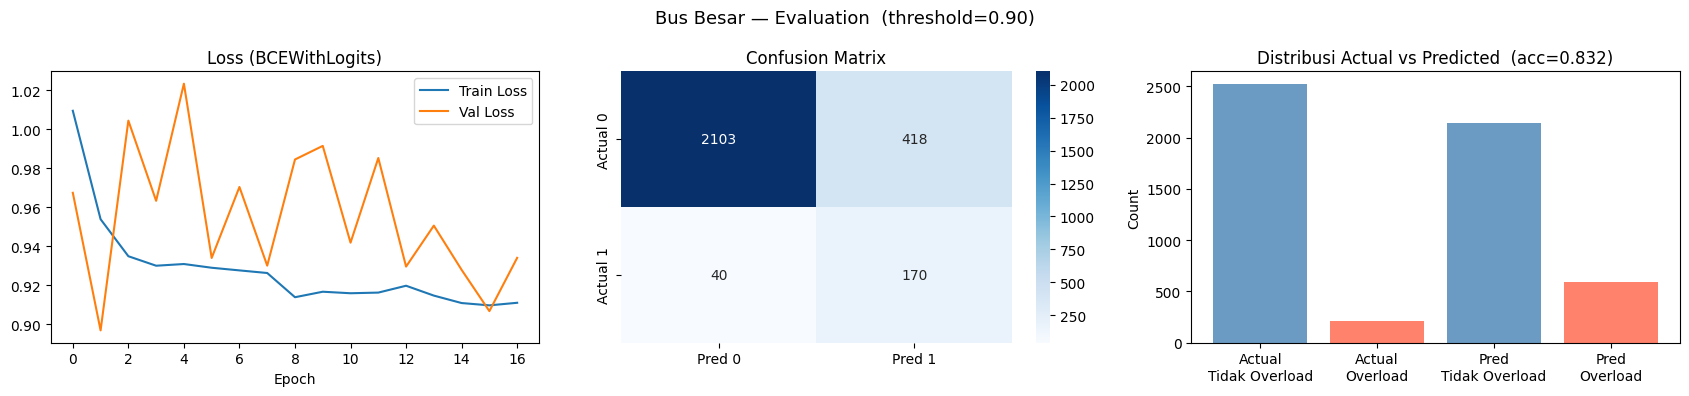

In [20]:
y_pred_big, y_actual_big, thresh_big = evaluate_model(
    model_big, X_te_big, y_te_big, history_big, bus_type='big'
)


In [21]:
alloc_big = predict_today_allocation(
    model_big, hourly_big, scaler_big,
    alloc_table=BIG_BUS_ALLOCATION,
    default_alloc=DEFAULT_BIG_ALLOC,
    bus_type='big',
    threshold=thresh_big
)
display_allocation_summary(alloc_big, bus_type='big')


Predicting today: 100%|██████████| 456/456 [00:01<00:00, 278.62corridor-hour/s]


  ALOKASI HARI INI — BUS BESAR
  Tanggal: 2024-06-30 (Sunday)
  Total slot (corridor × jam): 456
  Slot overload (butuh +1 bus): 149 (32.7%)

  Summary per Jam:


,hour,total_corridor,overload_count,avg_alokasi
0,5,24,0,3.33
1,6,24,0,3.33
2,7,24,24,4.33
3,8,24,24,4.33
4,9,24,24,4.33
5,10,24,0,3.33
6,11,24,2,3.42
7,12,24,3,3.46
8,13,24,1,3.38
9,14,24,0,3.33



  Corridor overload di SEMUA jam:
  Tidak ada

  Full allocation table:


,corridorID,hour,date,day_name,alokasi_eksisting,overload_prob,overload_pred,alokasi_hari_ini
0,1,5,2024-06-30,Sunday,5,0.007,0,5
1,1,6,2024-06-30,Sunday,5,0.008,0,5
2,1,7,2024-06-30,Sunday,5,0.970,1,6
3,1,8,2024-06-30,Sunday,5,0.979,1,6
4,1,9,2024-06-30,Sunday,5,0.979,1,6
...,...,...,...,...,...,...,...,...
451,T11,19,2024-06-30,Sunday,3,0.967,1,4
452,T11,20,2024-06-30,Sunday,3,0.013,0,3
453,T11,21,2024-06-30,Sunday,3,0.009,0,3
454,T11,22,2024-06-30,Sunday,3,0.040,0,3


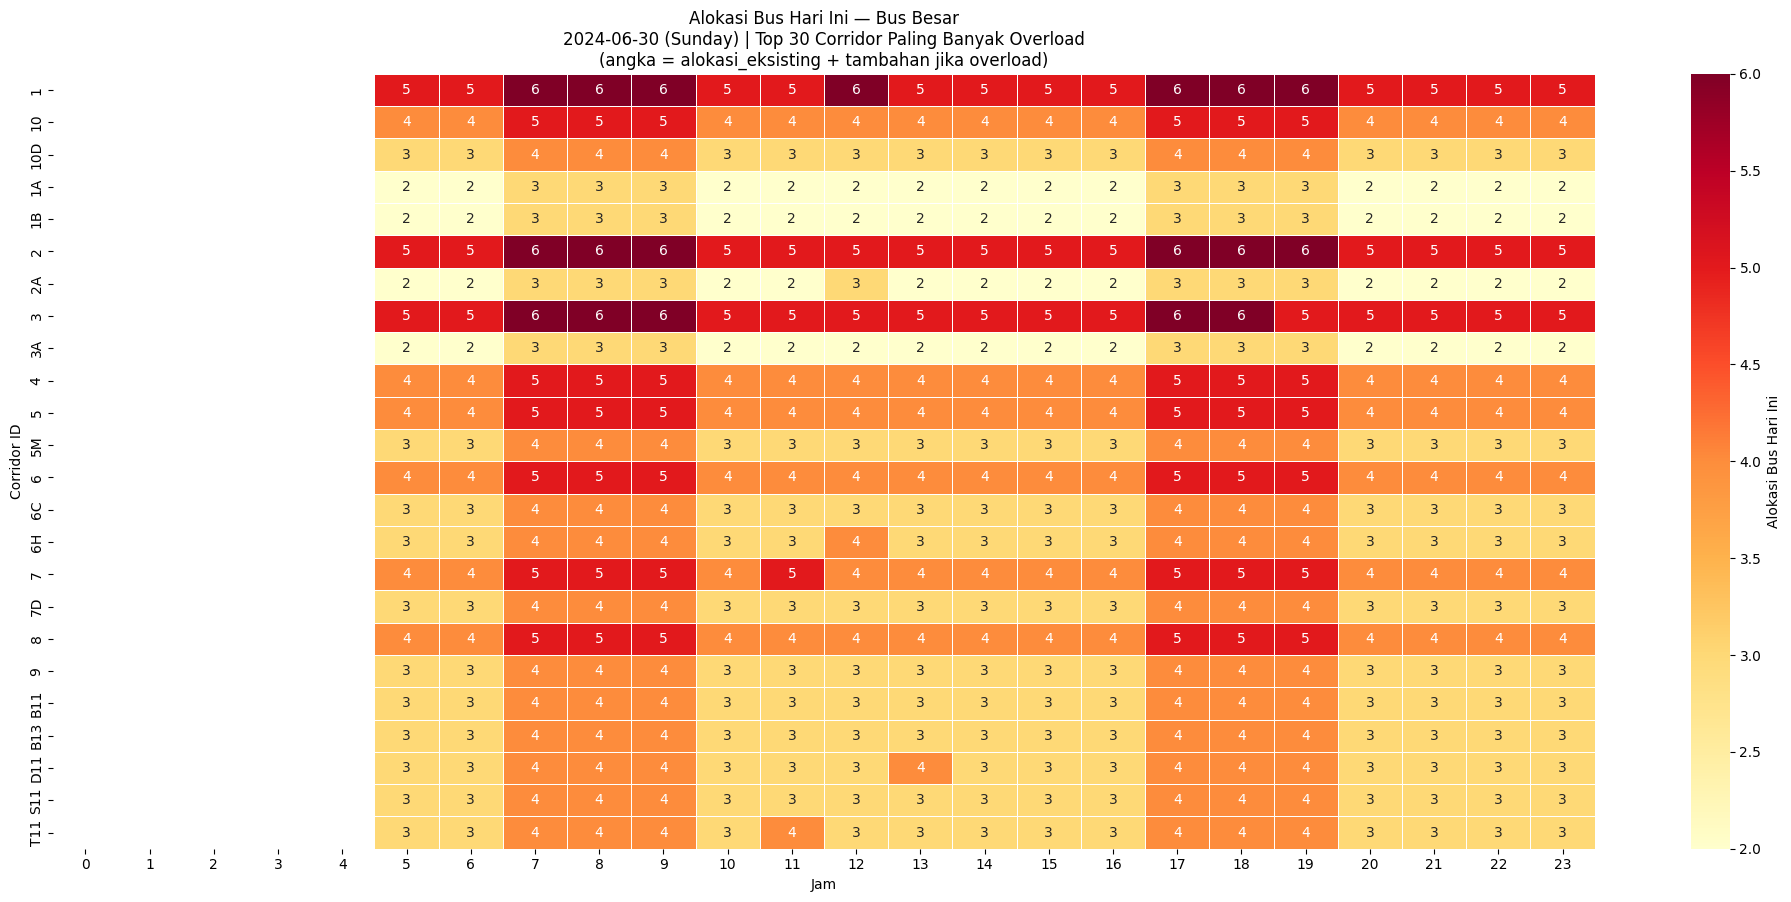

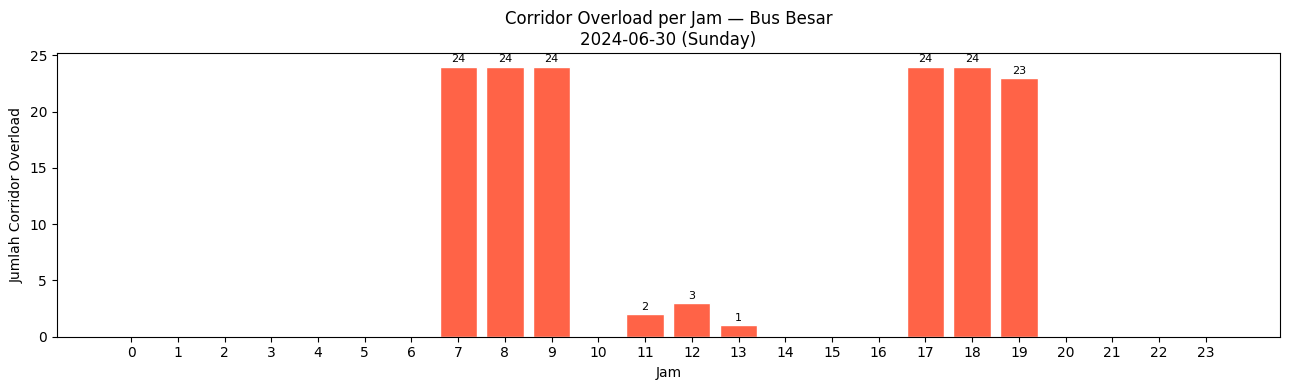

In [22]:
plot_allocation_heatmap(alloc_big, bus_type='big', top_n=30)
plot_overload_by_hour(alloc_big, bus_type='big')

---
## 🚐 BUS KECIL — Full Pipeline


In [23]:
print('=' * 60)
print('BUS KECIL')
print('=' * 60)

hourly_small = load_and_aggregate(SMALL_BUS_CSV, bus_type='small')
hourly_small = derive_labels(hourly_small, bus_type='small')

print('\nOverload distribution:')
print(hourly_small['overload'].value_counts().to_string())

BUS KECIL
[small] Rows: 287,434 | Dates: 2024-01-01 → 2024-06-30 | Corridors: 15


Aggregating [small]: 100%|██████████| 49690/49690 [04:34<00:00, 180.86slot/s]



Overload distribution:
overload
0    49680
1       10


In [24]:
X_small, y_small, meta_small = build_lstm_dataset(hourly_small)
print(f'X shape: {X_small.shape}  |  y shape: {y_small.shape}')

Building sequences: 100%|██████████| 285/285 [00:00<00:00, 467.22corridor-hour/s]


X shape: (47695, 7, 6)  |  y shape: (47695, 1)


In [25]:
X_tr_sm, y_tr_sm, X_te_sm, y_te_sm, meta_te_sm, scaler_sm, cutoff_sm = \
    scale_and_split(X_small, y_small, meta_small, hourly_small)

print(f'Cutoff date: {cutoff_sm}')

Computing split: 100%|██████████| 285/285 [00:00<00:00, 3131.72corridor-hour/s]

  Train sequences: 46,067  |  Test sequences: 1,628
Cutoff date: 2024-06-23 00:00:00


In [26]:
model_small, history_small = train_lstm(
    X_tr_sm, y_tr_sm, X_te_sm, y_te_sm,
    n_features=len(FEATURE_COLS)
)

  Pre-oversample → 0: 46,057  1: 10  auto pos_weight=15.0
  Oversampling: minority 10 → 30858  |  ratio maj:min = 46057:30858
  Post-oversample → 0: 46,057  1: 30,858


Training:  62%|██████▎   | 50/80 [08:14<04:56,  9.89s/epoch, train=0.0053, val=0.0217]

Early stopping at epoch 51
Best val_loss: 0.0135


  Best threshold: 0.50  (F1-overload=0.000)

[SMALL] Threshold=0.50  |  Accuracy: 0.9982
  Actual overload rate   : 0.000  (0 samples)
  Predicted overload rate: 0.002   (3 samples)
  Unique predicted classes: [0 1]

                precision    recall  f1-score   support

Tidak Overload       1.00      1.00      1.00      1628
      Overload       0.00      0.00      0.00         0

      accuracy                           1.00      1628
     macro avg       0.50      0.50      0.50      1628
  weighted avg       1.00      1.00      1.00      1628



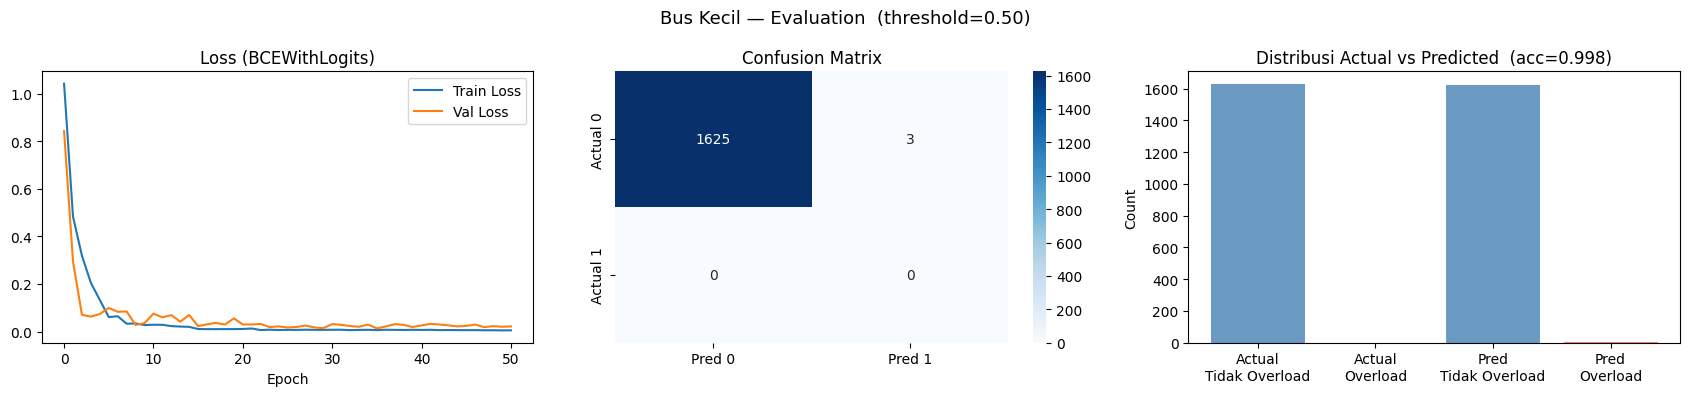

In [27]:
y_pred_sm, y_actual_sm, thresh_sm = evaluate_model(
    model_small, X_te_sm, y_te_sm, history_small, bus_type='small'
)


In [28]:
alloc_small = predict_today_allocation(
    model_small, hourly_small, scaler_sm,
    alloc_table=SMALL_BUS_ALLOCATION,
    default_alloc=DEFAULT_SMALL_ALLOC,
    bus_type='small',
    threshold=thresh_sm
)
display_allocation_summary(alloc_small, bus_type='small')


Predicting today: 100%|██████████| 285/285 [00:00<00:00, 287.01corridor-hour/s]


  ALOKASI HARI INI — BUS KECIL
  Tanggal: 2024-06-30 (Sunday)
  Total slot (corridor × jam): 285
  Slot overload (butuh +1 bus): 1 (0.4%)

  Summary per Jam:


,hour,total_corridor,overload_count,avg_alokasi
0,5,15,0,2.20
1,6,15,0,2.20
2,7,15,0,2.20
3,8,15,0,2.20
4,9,15,0,2.20
5,10,15,0,2.20
6,11,15,0,2.20
7,12,15,0,2.20
8,13,15,0,2.20
9,14,15,0,2.20



  Corridor overload di SEMUA jam:
  Tidak ada

  Full allocation table:


,corridorID,hour,date,day_name,alokasi_eksisting,overload_prob,overload_pred,alokasi_hari_ini
0,JAK.01,5,2024-06-30,Sunday,2,0.0,0,2
1,JAK.01,6,2024-06-30,Sunday,2,0.0,0,2
2,JAK.01,7,2024-06-30,Sunday,2,0.0,0,2
3,JAK.01,8,2024-06-30,Sunday,2,0.0,0,2
4,JAK.01,9,2024-06-30,Sunday,2,0.0,0,2
...,...,...,...,...,...,...,...,...
280,M7B,19,2024-06-30,Sunday,2,0.0,0,2
281,M7B,20,2024-06-30,Sunday,2,0.0,0,2
282,M7B,21,2024-06-30,Sunday,2,0.0,0,2
283,M7B,22,2024-06-30,Sunday,2,0.0,0,2


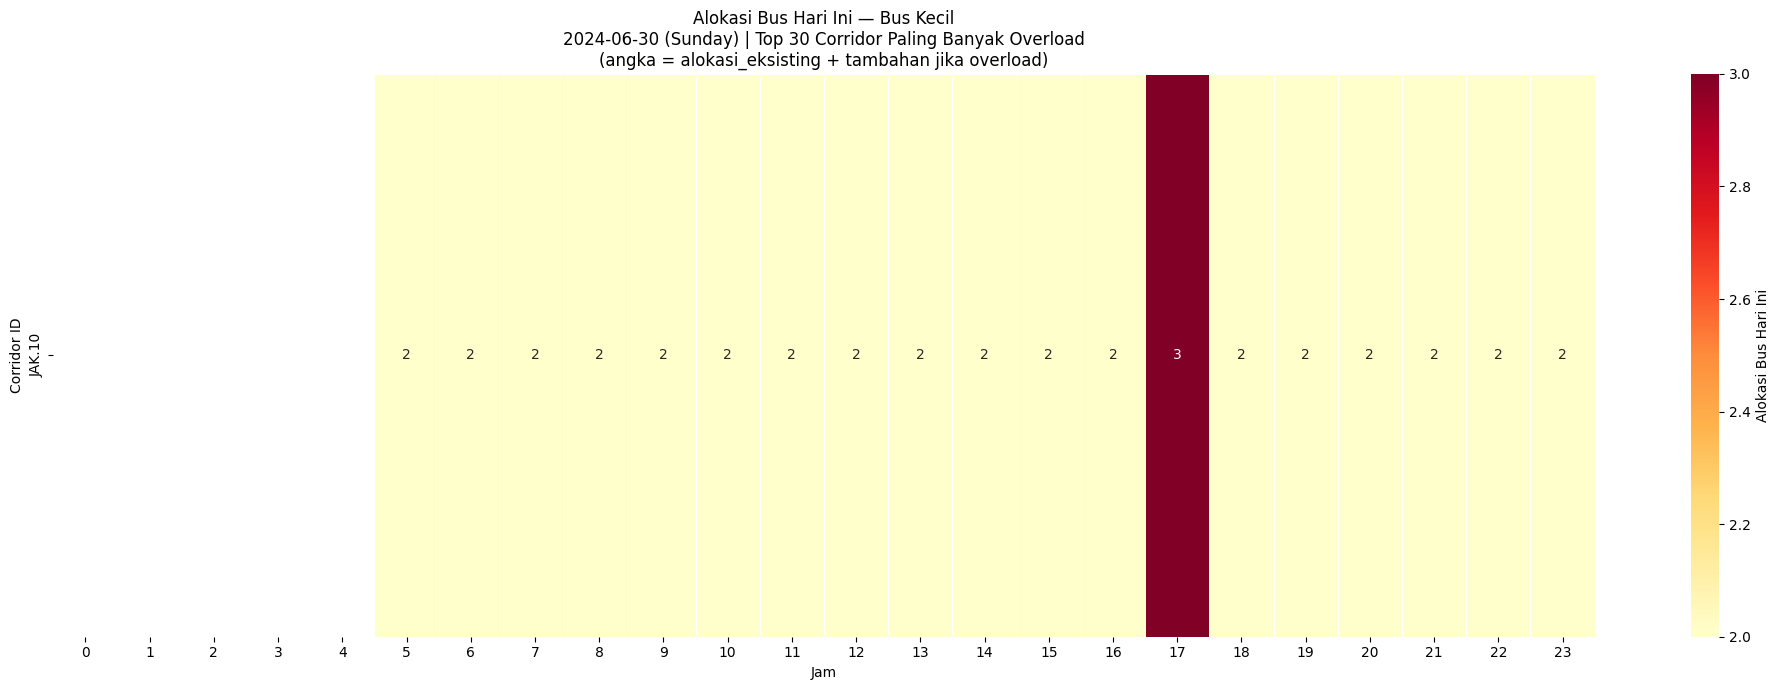

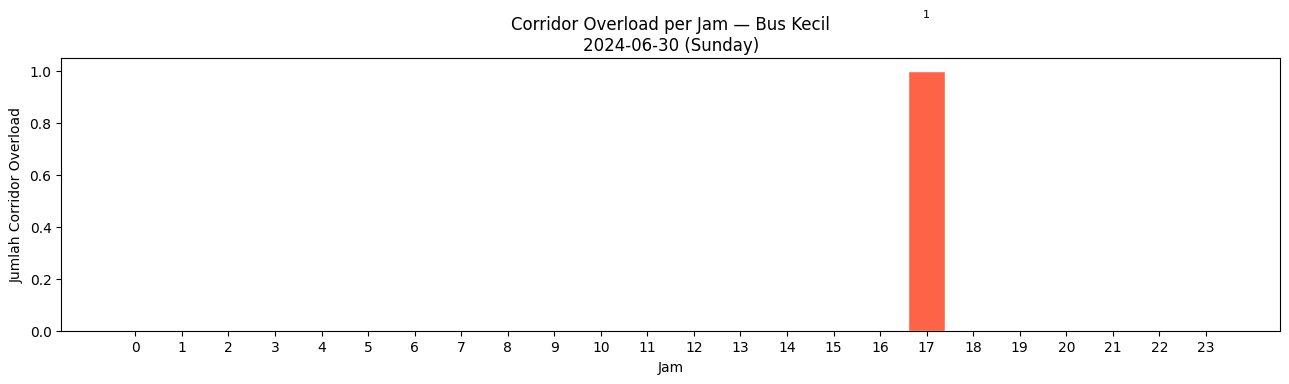

In [29]:
plot_allocation_heatmap(alloc_small, bus_type='small', top_n=30)
plot_overload_by_hour(alloc_small, bus_type='small')